In [51]:
!pip install pandas numpy matplotlib seaborn openpyxl

# Taller 01 - Adquisición, procesamiento y visualización de datos

## 1. Adquisición del dataset

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sqlite3

print("Entorno listo para trabajar")

Entorno listo para trabajar


In [4]:
df = pd.read_excel("Online Retail.xlsx")

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.shape

(541909, 8)

In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## 2. Limpieza y preparación de datos

In [10]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
df = df.dropna(subset=['Description'])

In [12]:
df = df.dropna(subset=['CustomerID'])

In [13]:
df.shape

(406829, 8)

In [15]:
df.duplicated().sum()

np.int64(5225)

In [16]:
df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df[df['Quantity'] < 0].shape

(8872, 8)

In [19]:
df[df['UnitPrice'] <= 0].shape

(40, 8)

In [20]:
df[df['Quantity'] < 0].shape

(8872, 8)

In [21]:
df = df[df['Quantity'] > 0]

In [22]:
df = df[df['UnitPrice'] > 0]

In [23]:
df[df['Quantity'] < 0].shape

(0, 8)

In [24]:
df[df['UnitPrice'] <= 0].shape

(0, 8)

In [25]:
df.shape

(392692, 8)

In [26]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [27]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 3. Almacenamiento en base de datos SQLite

In [28]:
conexion = sqlite3.connect("online_retail.db")

In [29]:
df.to_sql(
    "ventas",
    conexion,
    if_exists="replace",
    index=False
)

392692

In [30]:
consulta = pd.read_sql(
    "SELECT * FROM ventas LIMIT 5",
    conexion
)

consulta

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [31]:
conexion = sqlite3.connect("online_retail.db")

In [32]:
df.to_sql(
    "ventas",
    conexion,
    if_exists="replace",
    index=False
)

392692

In [33]:
consulta = pd.read_sql(
    "SELECT * FROM ventas LIMIT 5",
    conexion
)

consulta

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [34]:
df_sql = pd.read_sql(
    "SELECT * FROM ventas",
    conexion
)

df_sql.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 4. Análisis exploratorio de datos (EDA)

In [35]:
df_sql.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID,TotalAmount
count,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,560590.875047,13.119702,3.125914,15287.843865,22.631500
std,13087.063759,180.492832,22.241836,1713.539549,311.099224
min,536365.000000,1.000000,0.001000,12346.000000,0.001000
25%,549234.000000,2.000000,1.250000,13955.000000,4.950000
50%,561874.000000,6.000000,1.950000,15150.000000,12.450000
75%,572061.000000,12.000000,3.750000,16791.000000,19.800000
max,581587.000000,80995.000000,8142.750000,18287.000000,168469.600000


In [36]:
df_sql['CustomerID'].nunique()

4338

In [37]:
df_sql['Description'].nunique()

3877

In [38]:
df_sql['Country'].nunique()

37

In [39]:
df_sql['InvoiceDate'].min()

'2010-12-01 08:26:00'

In [40]:
df_sql['InvoiceDate'].max()

'2011-12-09 12:50:00'

In [41]:
df_sql['TotalAmount'].sum()

np.float64(8887208.894000001)

## 5. Visualización de datos

In [42]:
ventas_pais = (
    df_sql.groupby('Country')['TotalAmount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

ventas_pais

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalAmount, dtype: float64

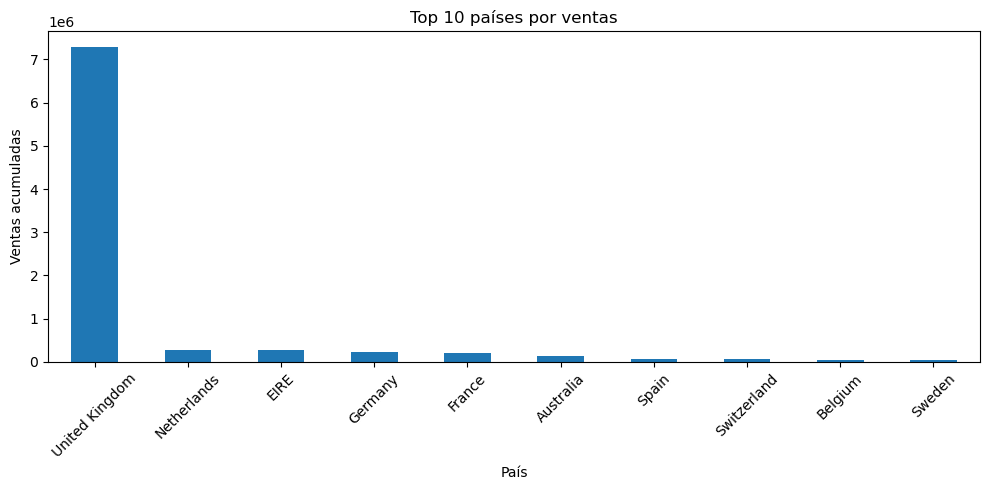

In [43]:
plt.figure(figsize=(10,5))

ventas_pais.plot(kind='bar')

plt.title("Top 10 países por ventas")
plt.xlabel("País")
plt.ylabel("Ventas acumuladas")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("ventas_por_pais.png")

plt.show()

In [44]:
productos = (
    df_sql.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

productos

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

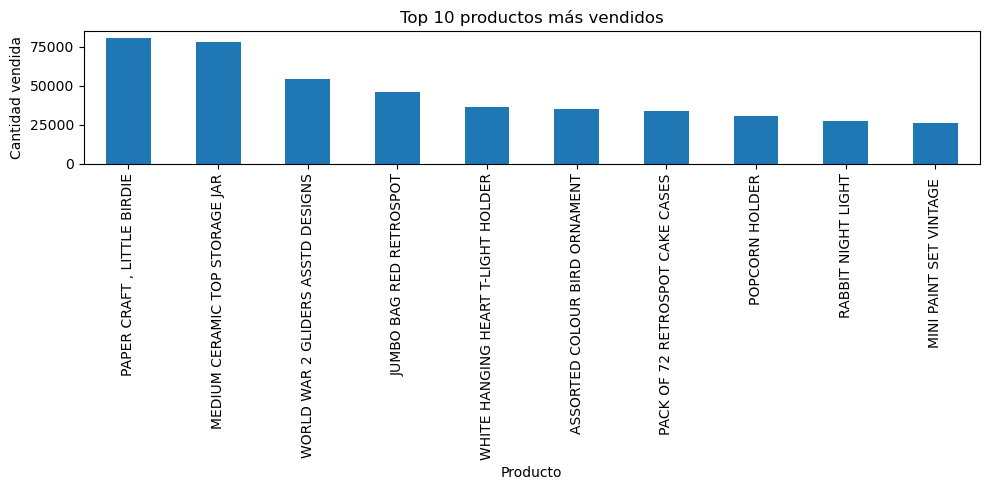

In [45]:
plt.figure(figsize=(10,5))

productos.plot(kind='bar')

plt.title("Top 10 productos más vendidos")
plt.xlabel("Producto")
plt.ylabel("Cantidad vendida")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("productos_mas_vendidos.png")

plt.show()

In [47]:
df_sql['InvoiceDate'] = pd.to_datetime(df_sql['InvoiceDate'])

In [48]:
df_sql['Month'] = df_sql['InvoiceDate'].dt.to_period('M')

In [49]:
ventas_mes = (
    df_sql.groupby('Month')['TotalAmount']
    .sum()
)

ventas_mes

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: TotalAmount, dtype: float64

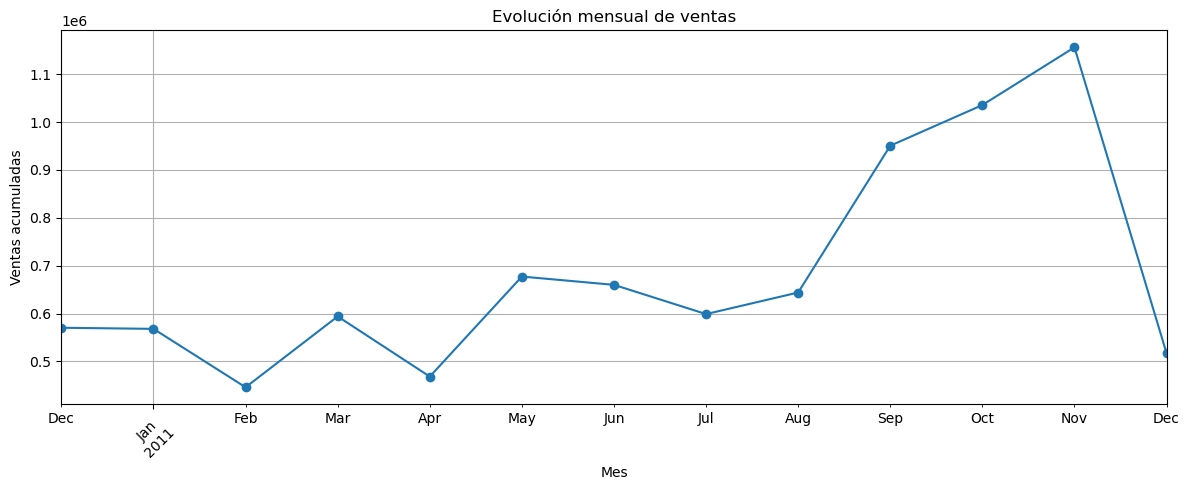

In [50]:
plt.figure(figsize=(12,5))

ventas_mes.plot(marker='o')

plt.title("Evolución mensual de ventas")
plt.xlabel("Mes")
plt.ylabel("Ventas acumuladas")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig("ventas_mensuales.png")

plt.show()